# 02 — Fine-tune SegFormer-B0 on FoodSeg103

**What this notebook does**
1. Loads a SegFormer-B0 encoder pretrained on ADE20K and swaps its head to 104 FoodSeg103 classes (103 food + background).
2. Fine-tunes on the FoodSeg103 train split using PyTorch MPS.
3. Evaluates every epoch on the validation split and saves the best-mIoU checkpoint to `../checkpoints/segformer_best/`.
4. Reports final per-class IoU at both 103-class granularity and 7-food-group granularity (via `assets/foodseg103_to_groups.csv`).

**Expected runtime on an M2 16GB** (image size 512, batch 2, 5 epochs): 5–7 hours.

**Iteration tip.** Before committing to a full run, set `QUICK_SMOKE_TEST = True` in the config cell — that trains on 200 images for 1 epoch in ~5 min so you can verify the whole pipeline end-to-end without waiting.

## 1. Config

In [1]:
# Toggle this for a 5-minute end-to-end sanity check:
QUICK_SMOKE_TEST = True

# Main training config
IMAGE_SIZE   = 512      # SegFormer's native resolution
BATCH_SIZE   = 2        # fits comfortably on M2 16GB at 512x512
NUM_EPOCHS   = 5
LEARNING_RATE = 6e-5
WEIGHT_DECAY = 1e-4
NUM_WORKERS  = 0        # must be 0 in Jupyter on macOS — spawn can't pickle notebook-defined transforms
EVAL_BATCH_SIZE = 4     # eval is cheaper without grads
SEED         = 42

BASE_CHECKPOINT = 'nvidia/segformer-b0-finetuned-ade-512-512'
SAVE_DIR        = '../checkpoints/segformer_best'
HISTORY_PATH    = '../checkpoints/train_history.json'

if QUICK_SMOKE_TEST:
    NUM_EPOCHS = 1
    SUBSET_SIZE = 200
    print('*** QUICK SMOKE TEST MODE — NOT A REAL TRAINING RUN ***')
else:
    SUBSET_SIZE = None

*** QUICK SMOKE TEST MODE — NOT A REAL TRAINING RUN ***


## 2. Environment

`PYTORCH_ENABLE_MPS_FALLBACK=1` lets PyTorch fall back to CPU for ops that MPS doesn't implement — a few show up in SegFormer and without this the run would crash.

In [2]:
import os
os.environ.setdefault('PYTORCH_ENABLE_MPS_FALLBACK', '1')
os.environ.setdefault('TOKENIZERS_PARALLELISM', 'false')

import sys, json, math, time, random
from pathlib import Path

import numpy as np
import torch
from torch.utils.data import DataLoader
from PIL import Image

sys.path.insert(0, os.path.abspath('..'))
from smartplate import load_class_to_group, ALL_GROUPS

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# SegFormer backward fails on MPS in PyTorch 2.7.x due to a C++ autograd engine
# view/stride bug that Python-level patches cannot intercept. CPU is used instead.
if torch.backends.mps.is_available():
    print('NOTE: MPS available but not used — PyTorch 2.7.x SegFormer backward bug.')
device = 'cpu'

print(f'Torch  : {torch.__version__}')
print(f'Device : {device}')
print(f'Checkpoint dir: {SAVE_DIR}')

NOTE: MPS available but not used — PyTorch 2.7.x SegFormer backward bug.
Torch  : 2.7.1
Device : cpu
Checkpoint dir: ../checkpoints/segformer_best


## 3. Dataset + label mappings

In [3]:
from datasets import load_dataset

ds = load_dataset('EduardoPacheco/FoodSeg103')
print(ds)

# Class names (from Wu et al., ACM MM 2021). Indices 0..103.
FOODSEG103_CLASSES = [
    'background', 'candy', 'egg tart', 'french fries', 'chocolate', 'biscuit', 'popcorn',
    'pudding', 'ice cream', 'cheese butter', 'cake', 'wine', 'milkshake', 'coffee', 'juice',
    'milk', 'tea', 'almond', 'red beans', 'cashew', 'dried cranberries', 'soy', 'walnut',
    'peanut', 'egg', 'apple', 'date', 'apricot', 'avocado', 'banana', 'strawberry', 'cherry',
    'blueberry', 'raspberry', 'mango', 'olives', 'peach', 'lemon', 'pear', 'fig', 'pineapple',
    'grape', 'kiwi', 'melon', 'orange', 'watermelon', 'steak', 'pork', 'chicken duck',
    'sausage', 'fried meat', 'lamb', 'sauce', 'crab', 'fish', 'shellfish', 'shrimp', 'soup',
    'bread', 'corn', 'hamburg', 'pizza', 'hanamaki baozi', 'wonton dumplings', 'pasta',
    'noodles', 'rice', 'pie', 'tofu', 'eggplant', 'potato', 'garlic', 'cauliflower', 'tomato',
    'kelp', 'seaweed', 'spring onion', 'rape', 'ginger', 'okra', 'lettuce', 'pumpkin',
    'cucumber', 'white radish', 'carrot', 'asparagus', 'bamboo shoots', 'broccoli',
    'celery stick', 'cilantro mint', 'snow peas', 'cabbage', 'bean sprouts', 'onion',
    'pepper', 'green beans', 'French beans', 'king oyster mushroom', 'shiitake',
    'enoki mushroom', 'oyster mushroom', 'white button mushroom', 'salad', 'other ingredients',
]
NUM_LABELS = len(FOODSEG103_CLASSES)  # 104
id2label = {i: n for i, n in enumerate(FOODSEG103_CLASSES)}
label2id = {n: i for i, n in enumerate(FOODSEG103_CLASSES)}

# Food-group mapping for group-level mIoU.
class_to_group = load_class_to_group('../assets/foodseg103_to_groups.csv')
print(f'{NUM_LABELS} classes, {len(class_to_group)} mapped to food groups.')

if SUBSET_SIZE is not None:
    ds['train']      = ds['train'].shuffle(seed=SEED).select(range(SUBSET_SIZE))
    ds['validation'] = ds['validation'].shuffle(seed=SEED).select(range(min(SUBSET_SIZE, len(ds['validation']))))
    print(f'Using subset: train={len(ds["train"])}  val={len(ds["validation"])}')

/Users/krishdembla/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'classes_on_image', 'id'],
        num_rows: 4983
    })
    validation: Dataset({
        features: ['image', 'label', 'classes_on_image', 'id'],
        num_rows: 2135
    })
})
104 classes, 96 mapped to food groups.
Using subset: train=200  val=200


## 4. Model + processor

Load the ADE20K-pretrained SegFormer-B0 encoder, then replace its classification head with one sized for our 104 classes. `ignore_mismatched_sizes=True` is required because the old head is 150-way (ADE20K) and we want 104-way.

In [4]:
from transformers import SegformerForSemanticSegmentation, SegformerImageProcessor

processor = SegformerImageProcessor(
    do_resize=True,
    size={'height': IMAGE_SIZE, 'width': IMAGE_SIZE},
    do_reduce_labels=False,   # our label 0 = background, not a void class
)

model = SegformerForSemanticSegmentation.from_pretrained(
    BASE_CHECKPOINT,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)
model.to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6
print(f'SegFormer-B0 trainable params: {n_params:.2f} M')

Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/segformer-b0-finetuned-ade-512-512 and are newly initialized because the shapes did not match:
- decode_head.classifier.bias: found shape torch.Size([150]) in the checkpoint and torch.Size([104]) in the model instantiated
- decode_head.classifier.weight: found shape torch.Size([150, 256, 1, 1]) in the checkpoint and torch.Size([104, 256, 1, 1]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


SegFormer-B0 trainable params: 3.74 M


## 5. Transforms + DataLoaders

Training augmentation is a random horizontal flip applied to both the image and the mask, then the `SegformerImageProcessor` handles resizing + ImageNet normalization. Validation skips the flip.

In [5]:
def train_transform(batch):
    images, labels = [], []
    for img, lbl in zip(batch['image'], batch['label']):
        img = img.convert('RGB')
        lbl_np = np.array(lbl)
        if random.random() < 0.5:
            img    = img.transpose(Image.FLIP_LEFT_RIGHT)
            lbl_np = np.ascontiguousarray(lbl_np[:, ::-1])
        images.append(img)
        labels.append(Image.fromarray(lbl_np))
    enc = processor(images=images, segmentation_maps=labels, return_tensors='pt')
    return enc

def val_transform(batch):
    images = [x.convert('RGB') for x in batch['image']]
    labels = [Image.fromarray(np.array(x)) for x in batch['label']]
    return processor(images=images, segmentation_maps=labels, return_tensors='pt')

train_ds = ds['train'].with_transform(train_transform)
val_ds   = ds['validation'].with_transform(val_transform)

def collate(batch):
    # squeeze(0) handles both [1, C, H, W] and [C, H, W] processor output shapes
    return {
        'pixel_values': torch.stack([b['pixel_values'].squeeze(0) for b in batch]),
        'labels':       torch.stack([b['labels'].squeeze(0) for b in batch]).long(),
    }

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=collate, num_workers=NUM_WORKERS, pin_memory=False,
)
val_loader = DataLoader(
    val_ds, batch_size=EVAL_BATCH_SIZE, shuffle=False,
    collate_fn=collate, num_workers=NUM_WORKERS, pin_memory=False,
)
print(f'Train: {len(train_ds)} samples, {len(train_loader)} batches')
print(f'Val  : {len(val_ds)} samples, {len(val_loader)} batches')

Train: 200 samples, 100 batches
Val  : 200 samples, 50 batches


## 6. Evaluation: per-class and per-group mIoU

We accumulate a $104\times104$ confusion matrix in a single pass and derive IoU per class from it. To compute the food-group mIoU we first remap predictions and ground truth through `class_to_group`, then repeat the IoU calculation on the 7 groups.

In [6]:
from tqdm.auto import tqdm

GROUP_NAMES = ('background',) + ALL_GROUPS   # 8 buckets incl. 'background'
GROUP_TO_ID = {g: i for i, g in enumerate(GROUP_NAMES)}

# 104-long vector: class_id -> group_id. Unmapped classes (drinks/sauces) -> background.
class_to_group_id = np.zeros(NUM_LABELS, dtype=np.int64)
for cid, gname in class_to_group.items():
    class_to_group_id[cid] = GROUP_TO_ID[gname]

def _iou_from_confmat(conf: np.ndarray):
    tp = np.diag(conf).astype(np.float64)
    fp = conf.sum(axis=0) - tp
    fn = conf.sum(axis=1) - tp
    denom = tp + fp + fn
    iou = np.where(denom > 0, tp / np.maximum(denom, 1), np.nan)
    return iou

def evaluate_model(model, loader, device):
    model.eval()
    conf = np.zeros((NUM_LABELS, NUM_LABELS), dtype=np.int64)
    running_loss, n_batches = 0.0, 0
    with torch.no_grad():
        for batch in tqdm(loader, desc='eval', leave=False):
            pixel_values = batch['pixel_values'].to(device).contiguous()
            labels       = batch['labels'].to(device).contiguous()
            out = model(pixel_values=pixel_values, labels=labels)
            running_loss += out.loss.item(); n_batches += 1
            # upsample logits to label resolution, then argmax
            logits = torch.nn.functional.interpolate(
                out.logits, size=labels.shape[-2:], mode='bilinear', align_corners=False,
            )
            preds = logits.argmax(dim=1).cpu().numpy().ravel()
            gt    = labels.cpu().numpy().ravel()
            conf += np.bincount(
                gt * NUM_LABELS + preds,
                minlength=NUM_LABELS * NUM_LABELS,
            ).reshape(NUM_LABELS, NUM_LABELS)
    per_class_iou = _iou_from_confmat(conf)
    miou_classes  = float(np.nanmean(per_class_iou))

    # group-level confusion matrix via class->group remapping
    n_groups = len(GROUP_NAMES)
    group_conf = np.zeros((n_groups, n_groups), dtype=np.int64)
    for gt_cls in range(NUM_LABELS):
        gt_g = class_to_group_id[gt_cls]
        for pr_cls in range(NUM_LABELS):
            group_conf[gt_g, class_to_group_id[pr_cls]] += conf[gt_cls, pr_cls]
    per_group_iou = _iou_from_confmat(group_conf)
    miou_groups   = float(np.nanmean(per_group_iou))

    pixel_acc = float(np.diag(conf).sum() / max(conf.sum(), 1))
    return {
        'val_loss':      running_loss / max(n_batches, 1),
        'miou_classes':  miou_classes,
        'miou_groups':   miou_groups,
        'pixel_acc':     pixel_acc,
        'per_class_iou': per_class_iou,
        'per_group_iou': per_group_iou,
    }

## 7. Training loop

Constant-LR AdamW. After each epoch we evaluate on the validation split and save the checkpoint if val mIoU (103-class) improves.

In [7]:
Path(SAVE_DIR).mkdir(parents=True, exist_ok=True)
Path(HISTORY_PATH).parent.mkdir(parents=True, exist_ok=True)

optimizer = torch.optim.AdamW(
    model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY,
)

history = []
best_miou = -1.0

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    t0 = time.time()
    running_loss, n_batches = 0.0, 0
    pbar = tqdm(train_loader, desc=f'epoch {epoch}/{NUM_EPOCHS}')
    for batch in pbar:
        pixel_values = batch['pixel_values'].to(device).contiguous()
        labels       = batch['labels'].to(device).contiguous()
        out = model(pixel_values=pixel_values, labels=labels)
        optimizer.zero_grad(set_to_none=True)
        out.loss.backward()
        optimizer.step()
        running_loss += out.loss.item(); n_batches += 1
        if n_batches % 50 == 0:
            pbar.set_postfix(loss=f'{running_loss/n_batches:.3f}')
    train_loss = running_loss / max(n_batches, 1)
    eval_stats = evaluate_model(model, val_loader, device)
    dt = time.time() - t0

    row = {
        'epoch':        epoch,
        'train_loss':   train_loss,
        'val_loss':     eval_stats['val_loss'],
        'miou_classes': eval_stats['miou_classes'],
        'miou_groups':  eval_stats['miou_groups'],
        'pixel_acc':    eval_stats['pixel_acc'],
        'seconds':      dt,
    }
    history.append(row)
    print(
        f'epoch {epoch}: train_loss={train_loss:.3f}  val_loss={eval_stats["val_loss"]:.3f}  '
        f'mIoU_103={eval_stats["miou_classes"]:.3f}  mIoU_7grp={eval_stats["miou_groups"]:.3f}  '
        f'pixelAcc={eval_stats["pixel_acc"]:.3f}  ({dt/60:.1f} min)'
    )

    if eval_stats['miou_classes'] > best_miou:
        best_miou = eval_stats['miou_classes']
        model.save_pretrained(SAVE_DIR)
        processor.save_pretrained(SAVE_DIR)
        np.save(Path(SAVE_DIR) / 'per_class_iou.npy', eval_stats['per_class_iou'])
        np.save(Path(SAVE_DIR) / 'per_group_iou.npy', eval_stats['per_group_iou'])
        print(f'  ↳ saved new best to {SAVE_DIR} (mIoU_103={best_miou:.3f})')

    with open(HISTORY_PATH, 'w') as f:
        json.dump(history, f, indent=2)

epoch 1/1: 100%|██████████| 100/100 [04:39<00:00,  2.80s/it, loss=3.904]
                                                     

epoch 1: train_loss=3.904  val_loss=3.220  mIoU_103=0.012  mIoU_7grp=0.125  pixelAcc=0.444  (6.1 min)
  ↳ saved new best to ../checkpoints/segformer_best (mIoU_103=0.012)


## 8. Final evaluation: per-class and per-group IoU tables

Reloads the best checkpoint (so these numbers match the saved model, not the last-epoch state).

In [8]:
import pandas as pd

best_model = SegformerForSemanticSegmentation.from_pretrained(SAVE_DIR).to(device)
final = evaluate_model(best_model, val_loader, device)
print(f'FINAL  mIoU_103={final["miou_classes"]:.3f}  mIoU_7grp={final["miou_groups"]:.3f}  pixelAcc={final["pixel_acc"]:.3f}')

pc = pd.DataFrame({
    'class_id':   np.arange(NUM_LABELS),
    'class_name': FOODSEG103_CLASSES,
    'iou':        final['per_class_iou'],
}).sort_values('iou', ascending=False)
print('\n--- top-15 classes by IoU ---')
print(pc.head(15).to_string(index=False))
print('\n--- bottom-15 classes by IoU (excl. NaN) ---')
print(pc.dropna().tail(15).to_string(index=False))
pc.to_csv('../figures/per_class_iou.csv', index=False)

pg = pd.DataFrame({
    'group': list(GROUP_NAMES),
    'iou':   final['per_group_iou'],
})
print('\n--- per food group ---')
print(pg.to_string(index=False))
pg.to_csv('../figures/per_group_iou.csv', index=False)

FINAL  mIoU_103=0.012  mIoU_7grp=0.125  pixelAcc=0.444

--- top-15 classes by IoU ---
 class_id    class_name      iou
        0    background 0.822879
       46         steak 0.046173
       48  chicken duck 0.027072
       47          pork 0.021658
       58         bread 0.020606
       73        tomato 0.018542
       80       lettuce 0.012924
       89 cilantro mint 0.007470
       70        potato 0.004986
       52         sauce 0.003359
       67           pie 0.003028
        8     ice cream 0.001571
       84        carrot 0.001538
       66          rice 0.000924
       10          cake 0.000770

--- bottom-15 classes by IoU (excl. NaN) ---
 class_id        class_name  iou
       55         shellfish  0.0
       54              fish  0.0
       53              crab  0.0
        1             candy  0.0
       51              lamb  0.0
       50        fried meat  0.0
        9     cheese butter  0.0
       37             lemon  0.0
       11              wine  0.0
       44 

## 9. Qualitative check — a few val images

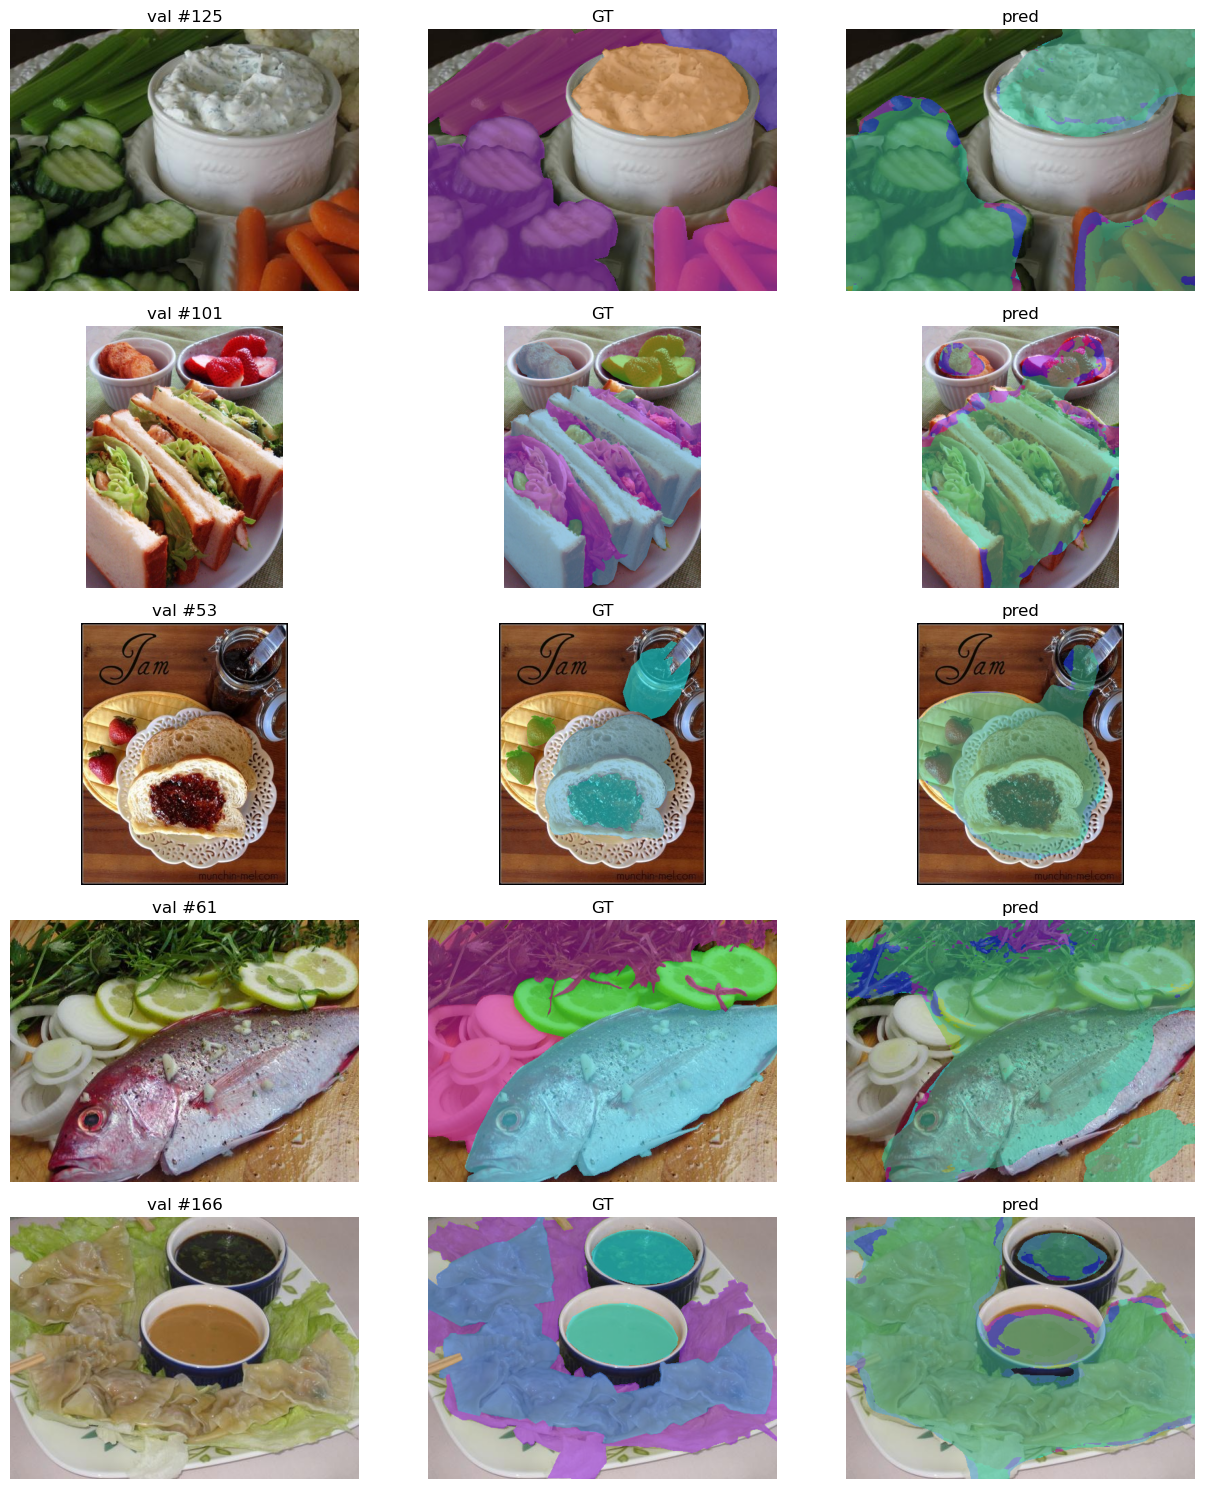

In [9]:
import matplotlib.pyplot as plt
from smartplate import overlay_mask, predict_mask

best_model.eval()
n_show = 5
rng = np.random.default_rng(0)
val_indices = rng.choice(len(ds['validation']), size=n_show, replace=False)

fig, axes = plt.subplots(n_show, 3, figsize=(13, 3 * n_show))
for row, idx in enumerate(val_indices):
    ex   = ds['validation'][int(idx)]
    img  = ex['image'].convert('RGB')
    gt   = np.array(ex['label'])
    pred = predict_mask(best_model, processor, img, device=device)
    axes[row, 0].imshow(img);                     axes[row, 0].set_title(f'val #{idx}'); axes[row, 0].axis('off')
    axes[row, 1].imshow(overlay_mask(img, gt,   num_classes=NUM_LABELS)); axes[row, 1].set_title('GT');   axes[row, 1].axis('off')
    axes[row, 2].imshow(overlay_mask(img, pred, num_classes=NUM_LABELS)); axes[row, 2].set_title('pred'); axes[row, 2].axis('off')

fig.tight_layout()
fig.savefig('../figures/qualitative_segformer.png', dpi=140)
plt.show()

## Next steps
1. Train ResNet50 classification baseline in `03_train_baseline.ipynb`.
2. Wire the saved `../checkpoints/segformer_best/` into the end-to-end demo `04_demo.ipynb`.